# Downscaling Time Series Using Gaussian Copulas
This file demonstrates code available in `solarspatialtools.synthirrad.copula`, which implements methods described by Widén and Munkhammar [1] for downscaling of irradiance using spatiotemporally correlated Gaussian Copulas. The implementation is based upon Matlab code shared by the original authors.

[1] Joakim Widén and Joakim Munkhammar, "Spatio-Temporal Downscaling of Hourly Solar irradiance Data Using Gaussian Copulas," 2019 IEEE 46th Photovoltaic Specialists Conference (PVSC), Chicago, IL, USA, 2019, pp. 3172-3178, doi: https://dx.doi.org/10.1109/PVSC40753.2019.8980922.

## Setup
Perform needed imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from solarspatialtools import spatial
from solarspatialtools.synthirrad.copula import downscale, downscale_multihour, DEFAULT_PARAMS

To generate time series for a distributed site, we need to provide the following parameters:
- `times`: A pandas DatetimeIndex of the times for which to generate data.
- `e_pos`: A 1D array of the east-west positions of the sites for
- `n_pos`: A 1D array of the north-south positions of the sites for which to generate data.
- `cloud_spd`: The cloud speed in m/s.
- `cloud_dir`: The cloud direction in degrees, where 0 is east measured positive CCW
- `mean_csi`: the mean clear-sky index for this time period
- `params`: A dictionary of curve fit parameters for the model, which can be generated by fitting to data or taken from the original paper. See `copula._process_params` for details on the parameters and their meaning. The fit values derived in the original paper are available in `copula.DEFAULT_PARAMS`

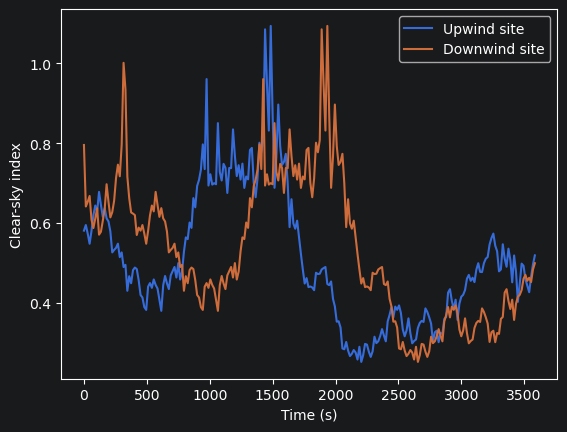

In [18]:
cloud_spd = 1
cloud_dir = 0

# Hourly clearsky
mean_csi = 0.52

e_pos = np.array([ 0, 450])
n_pos = np.array([ 0,   0])

times = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 00:59:59', freq='15s')

c = downscale(times, e_pos, n_pos, cloud_spd, cloud_dir, mean_csi, DEFAULT_PARAMS, seed=42, scale=True, noneg=True)

plt.plot((times-times[0]).total_seconds(), c)
plt.xlabel("Time (s)")
plt.ylabel("Clear-sky index")
plt.legend(['Upwind site', 'Downwind site']);


The relationship between space and time in the model occurs due to cloud advection. The cloud speed and direction, along with the spatial positions of the sites, determine the temporal correlation between sites. With a cloud_spd of 1 m/s and a cloud direction of 0 degrees, the cloud is moving eastward at 1 m/s. The two sites are arranged in the cloud direction 450 m spacing. This means that there will be a perfect correlation between the sites with a delay of 450 seconds, as visible by the delay between the two time series.

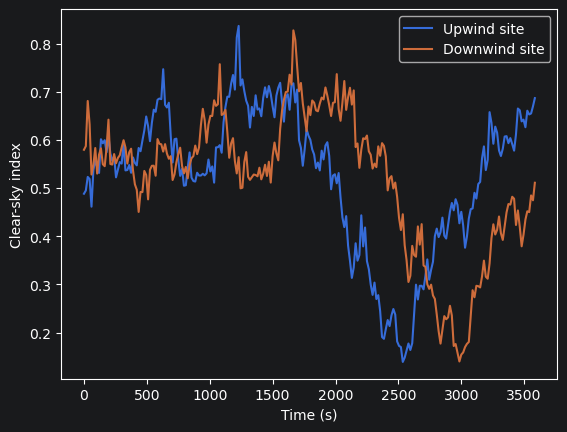

In [19]:
e_pos = np.array([ 0, 451])
n_pos = np.array([ 0,   0])

times = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 00:59:59', freq='15s')

c = downscale(times, e_pos, n_pos, cloud_spd, cloud_dir, mean_csi, DEFAULT_PARAMS, seed=42, scale=True, noneg=True)

plt.plot((times-times[0]).total_seconds(), c)
plt.xlabel("Time (s)")
plt.ylabel("Clear-sky index")
plt.legend(['Upwind site', 'Downwind site']);

We could generate a cloud field by generating a grid of points with spatial separation matching the timescale separation.

In [ ]:
cld_spd = 10
dt = 30
cld_dir = 1

mean_csi = 0.7

times = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 01:00:00', freq=f'{dt}s')

e_pos = np.zeros(len(times))
n_pos = np.arange(len(times)) * cld_spd*dt  # cld_spd * dt



c = downscale(times, e_pos, n_pos, cloud_spd, cloud_dir, mean_csi, DEFAULT_PARAMS, seed=42, scale=True, noneg=True)

plt.imshow(c)
plt.axis('equal')